# Malware in image detection using CNN

In [1]:
# Cell 0 -- insert data
import kagglehub

# Download latest version
path = kagglehub.dataset_download("manmandes/malimg")

print("Path to dataset files:", path)

C:\Users\Nguyen Thien Khai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\Nguyen Thien Khai\.cache\kagglehub\datasets\manmandes\malimg\versions\1


In [3]:
# Cell 1 -- Check Malimg Dataset Root & Folder Structure 

import os

DATA_DIR = os.path.join(path, "malimg_dataset")

print("Dataset Root:", DATA_DIR)
print("-" * 60)

# List items in root
root_items = os.listdir(DATA_DIR)
print("Items inside root:", root_items)

print("\nChecking structure:")
for item in root_items:
    item_path = os.path.join(DATA_DIR, item)
    
    if os.path.isdir(item_path):
        print(f"\n📁 {item}/  (directory)")
        
        # list class folders under train/val/test
        sub_items = sorted(os.listdir(item_path))
        print(f"  Contains {len(sub_items)} subfolders. Example:", sub_items[:10])
    else:
        print(f"📄 {item} (file)")


Dataset Root: C:\Users\Nguyen Thien Khai\.cache\kagglehub\datasets\manmandes\malimg\versions\1\malimg_dataset
------------------------------------------------------------
Items inside root: ['test', 'train', 'val']

Checking structure:

📁 test/  (directory)
  Contains 25 subfolders. Example: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A']

📁 train/  (directory)
  Contains 25 subfolders. Example: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A']

📁 val/  (directory)
  Contains 25 subfolders. Example: ['Adialer.C', 'Agent.FYI', 'Allaple.A', 'Allaple.L', 'Alueron.gen!J', 'Autorun.K', 'C2LOP.P', 'C2LOP.gen!g', 'Dialplatform.B', 'Dontovo.A']


In [4]:
# CELL 2 — Protobuf patch (safe to run even if not needed)

from google.protobuf import message_factory as _message_factory
if not hasattr(_message_factory.MessageFactory, "GetPrototype"):
    def _GetPrototype(self, descriptor):
        return self.GetMessageClass(descriptor)
    _message_factory.MessageFactory.GetPrototype = _GetPrototype
print("Protobuf patch applied (if required).")


Protobuf patch applied (if required).


# Imports Liberies and Configuration

In [ ]:
# CELL 3 — Imports & Config

import os, random, time, math
from glob import glob
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers # type: ignore

from sklearn.utils import class_weight
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split


# Hyperparameters (as in the project)
IMAGE_SIZE = (256, 256)
BATCH_SIZE = 32
LR = 0.001
INITIAL_EPOCHS = 10
RETRAIN_EPOCHS = 15
SEED = 42

# Split ratios (project used floor(n*0.2) twice)
SPLIT_TEST = 0.2
SPLIT_VAL  = 0.2

# Repro
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TF:", tf.__version__, "| Data root:", DATA_DIR)


C:\Users\Nguyen Thien Khai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TF: 2.17.0 | Data root: /kaggle/input/malimg/malimg_dataset


In [1]:
import tensorflow as tf
import os

# Đôi khi cần báo cho TF biết GPU đang ở đâu (đặc thù Windows)
# Bạn có thể cần thêm các dòng này nếu máy không nhận GPU ngay
# os.environ['CUDA_VISIBLE_DEVICES'] = '0'

print(f"TensorFlow Version: {tf.__version__}")
gpus = tf.config.list_physical_devices('GPU')

if gpus:
    print(f"✅ THÀNH CÔNG! Đã nhận {len(gpus)} GPU:")
    for gpu in gpus:
        print(f" - {gpu.name}")
else:
    print("❌ Chưa nhận GPU.")

C:\Users\Nguyen Thien Khai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


TensorFlow Version: 2.17.0
❌ Chưa nhận GPU.


# Data Pre-processing and Image Construction

In [16]:
# CELL 4 — Quick check of Dataset Structure (no listing of every image)

DATA_DIR = os.path.join(path, "malimg_dataset")
print("Root contents:", sorted(os.listdir(DATA_DIR)))
for s in ["train","val","test"]:
    p = os.path.join(DATA_DIR, s)
    print(s, "exists?" , os.path.isdir(p), " -> #classes:",
          len([d for d in os.listdir(p) if os.path.isdir(os.path.join(p,d))]) if os.path.isdir(p) else 0)


Root contents: ['test', 'train', 'val']
train exists? True  -> #classes: 25
val exists? True  -> #classes: 25
test exists? True  -> #classes: 25


In [17]:
# CELL 5 — Combine Images from train/val/test into a single DataFrame.

def collect_all_images(root):
    records = []
    for split in ["train","val","test"]:
        split_dir = os.path.join(root, split)
        if not os.path.isdir(split_dir):
            continue
        for cls in sorted(os.listdir(split_dir)):
            cls_dir = os.path.join(split_dir, cls)
            if not os.path.isdir(cls_dir):
                continue
            imgs = glob(os.path.join(cls_dir, "*"))
            imgs = [p for p in imgs if p.lower().endswith(('.png','.jpg','.jpeg'))]
            for p in imgs:
                records.append((p, cls))
    return pd.DataFrame(records, columns=["filepath","label"])

df_all = collect_all_images(DATA_DIR)
print("Total images combined:", len(df_all))
print("Total classes:", df_all['label'].nunique())
df_all.head()


Total images combined: 9339
Total classes: 25


,filepath,label
0,C:\Users\Nguyen Thien Khai\.cache\kagglehub\da...,Adialer.C
1,C:\Users\Nguyen Thien Khai\.cache\kagglehub\da...,Adialer.C
2,C:\Users\Nguyen Thien Khai\.cache\kagglehub\da...,Adialer.C
3,C:\Users\Nguyen Thien Khai\.cache\kagglehub\da...,Adialer.C
4,C:\Users\Nguyen Thien Khai\.cache\kagglehub\da...,Adialer.C


Total classes: 25


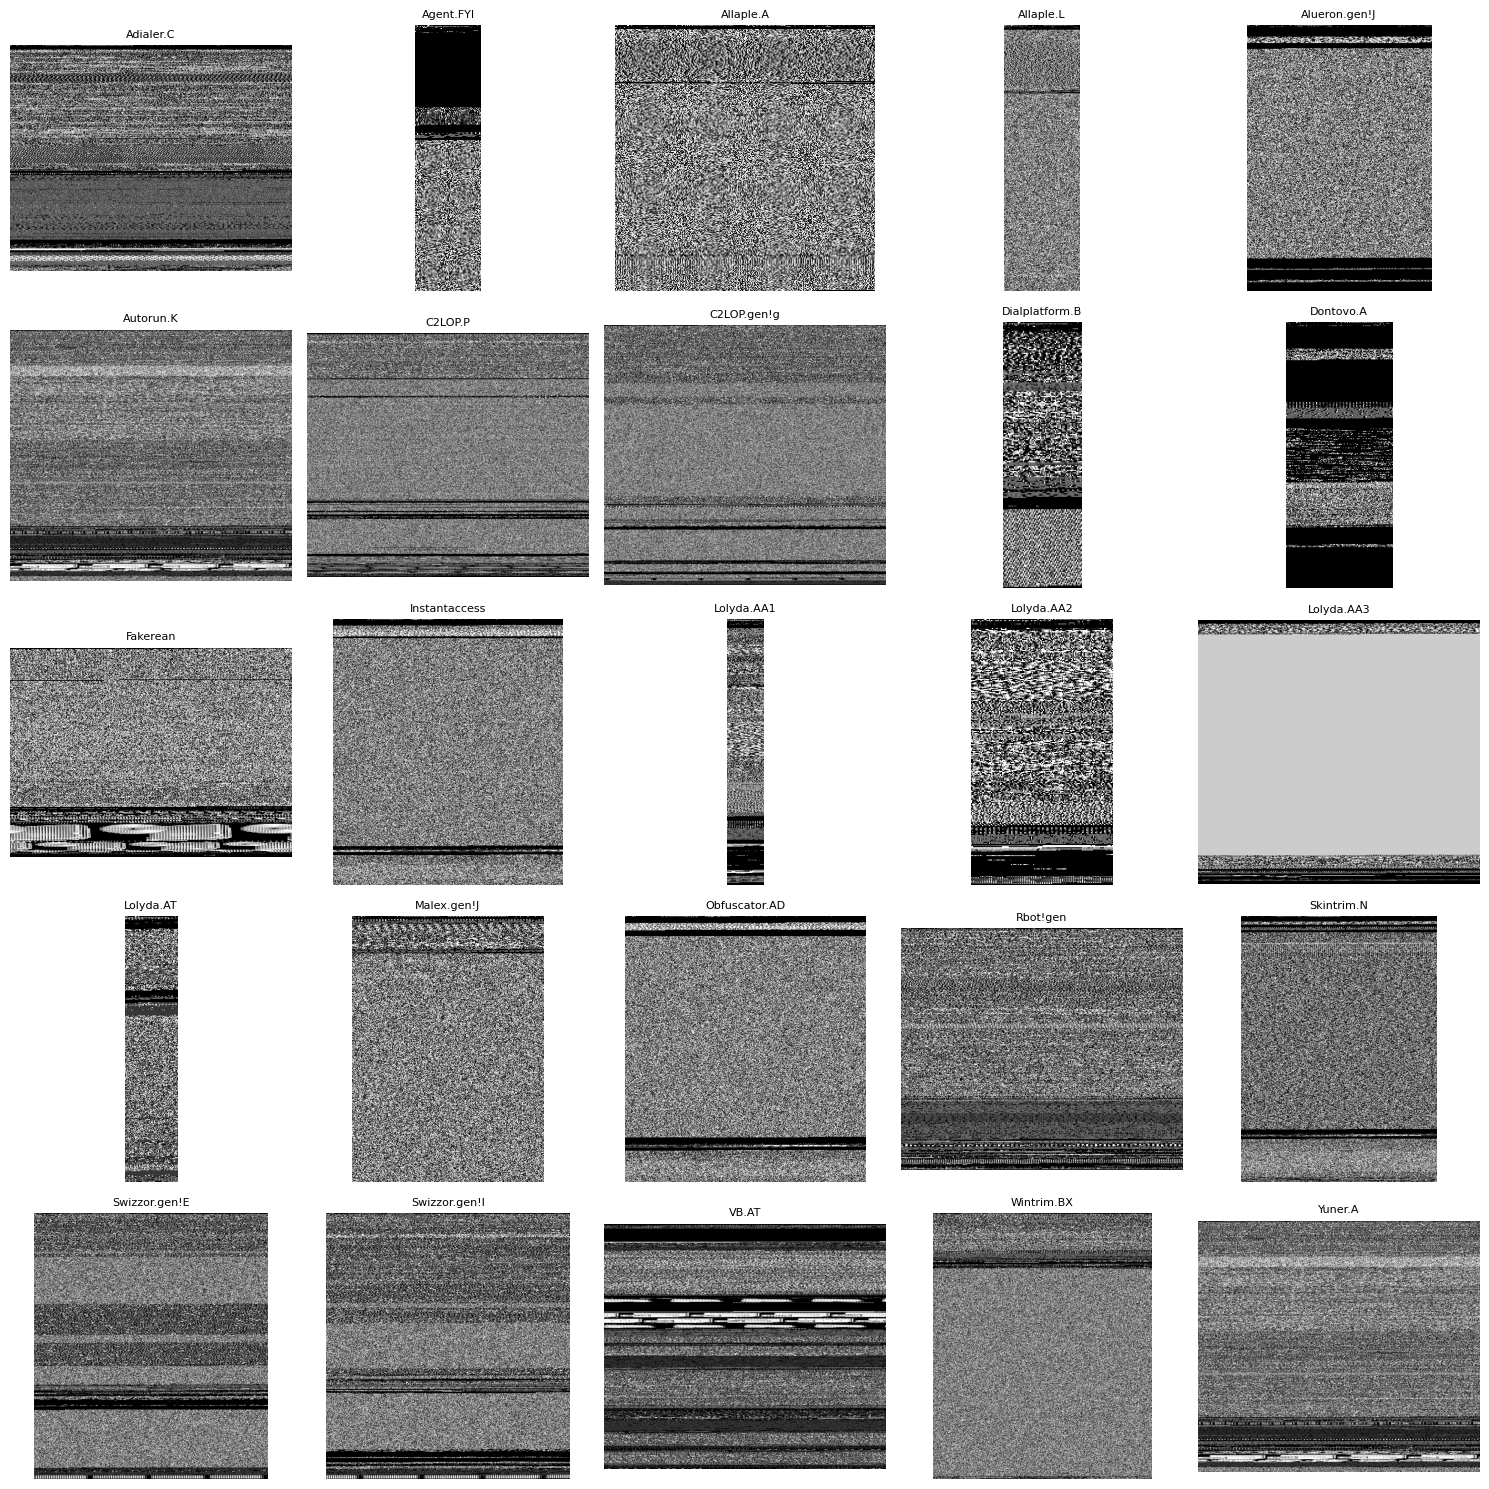

In [18]:
# Cell 5.5 — Grayscale Sample Image from each class

import matplotlib.pyplot as plt
import cv2
import random

unique_classes = sorted(df_all['label'].unique())
num_classes = len(unique_classes)

print("Total classes:", num_classes)

# Grid size (5 rows × 5 columns for 25 classes)
cols = 5
rows = (num_classes // cols) + (num_classes % cols > 0)

plt.figure(figsize=(15, 15))

for idx, cls in enumerate(unique_classes):
    sample_paths = df_all[df_all['label'] == cls]['filepath'].tolist()
    img_path = random.choice(sample_paths)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.subplot(rows, cols, idx + 1)
    plt.imshow(img)
    plt.title(cls, fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()


In [19]:
# CELL 6 — Recreate per-class 60% / 20% / 20% split

def stratified_per_class(df, test_ratio=SPLIT_TEST, val_ratio=SPLIT_VAL, seed=SEED):
    train_rows, val_rows, test_rows = [], [], []
    for cls, group in df.groupby("label"):
        files = group['filepath'].tolist()
        random.Random(seed).shuffle(files)
        n = len(files)
        n_test = int(math.floor(n * test_ratio))
        n_val  = int(math.floor(n * val_ratio))
        test_f = files[:n_test]
        val_f  = files[n_test:n_test+n_val]
        train_f= files[n_test+n_val:]
        test_rows += [(p, cls) for p in test_f]
        val_rows  += [(p, cls) for p in val_f]
        train_rows += [(p, cls) for p in train_f]
    train_df = pd.DataFrame(train_rows, columns=["filepath","label"]).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    val_df   = pd.DataFrame(val_rows,   columns=["filepath","label"]).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    test_df  = pd.DataFrame(test_rows,  columns=["filepath","label"]).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return train_df, val_df, test_df

train_df, val_df, test_df = stratified_per_class(df_all, SPLIT_TEST, SPLIT_VAL, SEED)
print("Sizes -> Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))
print("Example class counts (train):")
display(train_df['label'].value_counts().head(10))


Sizes -> Train: 5623 Val: 1858 Test: 1858
Example class counts (train):


label
Allaple.A        1771
Allaple.L         955
Yuner.A           480
Instantaccess     259
VB.AT             246
Fakerean          229
Lolyda.AA1        129
Alueron.gen!J     120
C2LOP.gen!g       120
Lolyda.AA2        112
Name: count, dtype: int64

In [20]:
# CELL 7 — Class Names & Mapping 

CLASS_NAMES = sorted(train_df['label'].unique())
NUM_CLASSES = len(CLASS_NAMES)
label_to_idx = {c:i for i,c in enumerate(CLASS_NAMES)}
idx_to_label = {i:c for c,i in label_to_idx.items()}

print("Num classes:", NUM_CLASSES)
print("Sample mapping:", list(label_to_idx.items())[:8])


Num classes: 25
Sample mapping: [('Adialer.C', 0), ('Agent.FYI', 1), ('Allaple.A', 2), ('Allaple.L', 3), ('Alueron.gen!J', 4), ('Autorun.K', 5), ('C2LOP.P', 6), ('C2LOP.gen!g', 7)]


In [21]:
# CELL 8 — Build tf.data datasets 

AUTOTUNE = tf.data.AUTOTUNE

def preprocess(path, label):
    img = tf.io.read_file(path)
    img = tf.io.decode_png(img, channels=3)  # or decode_image
    img = tf.image.convert_image_dtype(img, tf.float32)
    img = tf.image.resize(img, IMAGE_SIZE)
    return img, tf.cast(label, tf.int32)

def df_to_tf_dataset(df, shuffle=True, batch_size=BATCH_SIZE):
    paths = df['filepath'].values
    labels = df['label'].map(label_to_idx).values.astype(np.int32)
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(paths), seed=SEED)
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    ds = ds.prefetch(AUTOTUNE)
    return ds

train_ds = df_to_tf_dataset(train_df, shuffle=True)
val_ds   = df_to_tf_dataset(val_df, shuffle=False)
test_ds  = df_to_tf_dataset(test_df, shuffle=False)

# Quick check
for imgs, labs in train_ds.take(1):
    print("Batch shapes:", imgs.shape, labs.shape)


Batch shapes: (32, 256, 256, 3) (32,)


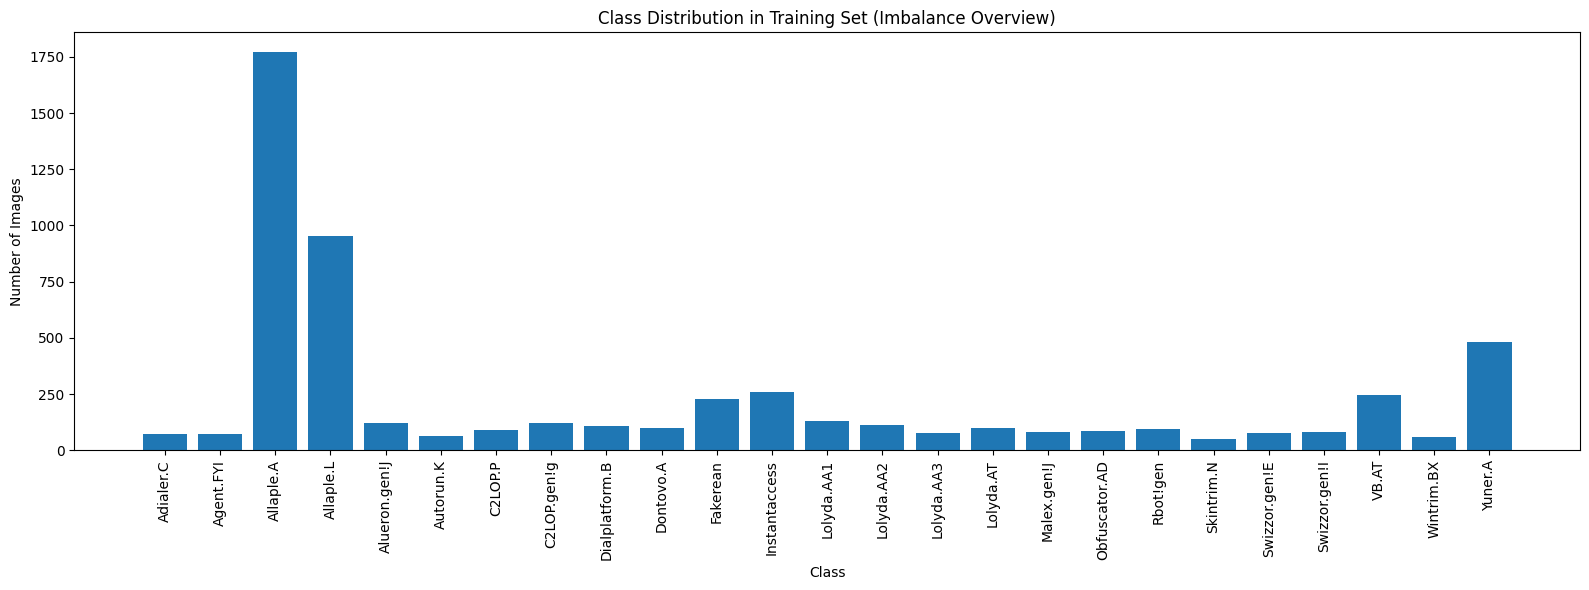


Class counts per class:

Adialer.C: 74
Agent.FYI: 70
Allaple.A: 1771
Allaple.L: 955
Alueron.gen!J: 120
Autorun.K: 64
C2LOP.P: 88
C2LOP.gen!g: 120
Dialplatform.B: 107
Dontovo.A: 98
Fakerean: 229
Instantaccess: 259
Lolyda.AA1: 129
Lolyda.AA2: 112
Lolyda.AA3: 75
Lolyda.AT: 97
Malex.gen!J: 82
Obfuscator.AD: 86
Rbot!gen: 96
Skintrim.N: 48
Swizzor.gen!E: 78
Swizzor.gen!I: 80
VB.AT: 246
Wintrim.BX: 59
Yuner.A: 480


In [22]:
# CELL 8.5 — Class Imbalance Distribution

import matplotlib.pyplot as plt

class_counts = train_df['label'].value_counts().sort_index()

plt.figure(figsize=(16, 6))
plt.bar(class_counts.index, class_counts.values)
plt.xticks(rotation=90)
plt.title("Class Distribution in Training Set (Imbalance Overview)")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()

print("\nClass counts per class:\n")
for cls, count in zip(class_counts.index, class_counts.values):
    print(f"{cls}: {count}")


Sample class weights: [(0, 3.0394594594594593), (1, 3.213142857142857), (2, 0.1270016939582157), (3, 0.23551832460732985), (4, 1.8743333333333334), (5, 3.514375), (6, 2.555909090909091), (7, 1.8743333333333334)]


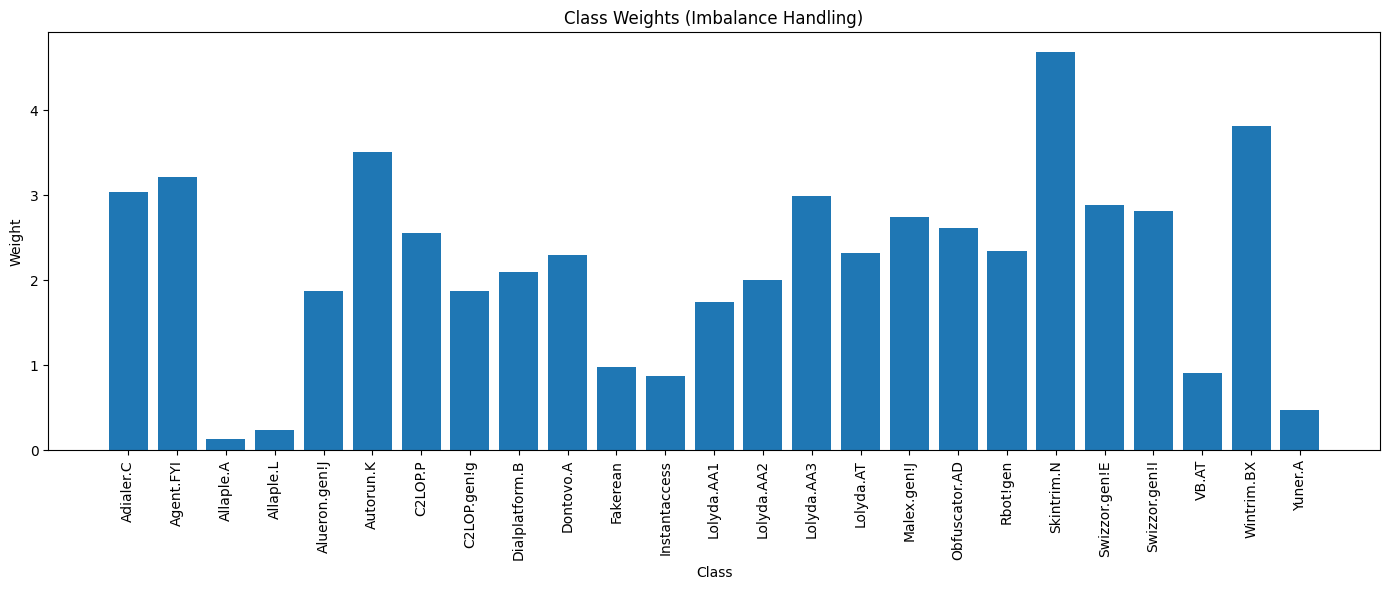

In [23]:
# CELL 9 — Compute Class Weights (sklearn balanced)

from sklearn.utils import class_weight
import matplotlib.pyplot as plt

# Numeric labels for training set
y_train_idx = train_df['label'].map(label_to_idx).values

# Compute class weights using sklearn's "balanced" formula
sk_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_idx),
    y=y_train_idx
)

class_weights = {i: float(w) for i, w in enumerate(sk_weights)}

print("Sample class weights:", list(class_weights.items())[:8])


# ---------- Plot Class Weights ----------

plt.figure(figsize=(14, 6))
plt.bar(range(len(class_weights)), list(class_weights.values()))
plt.xticks(range(len(class_weights)), CLASS_NAMES, rotation=90)
plt.title("Class Weights (Imbalance Handling)")
plt.xlabel("Class")
plt.ylabel("Weight")
plt.tight_layout()
plt.show()


In [25]:
# CELL 10 — Use existing strategy (safe for multi-GPU)

strategy = tf.distribute.get_strategy()
print("Using strategy:", strategy)
print("Number of devices:", strategy.num_replicas_in_sync)


Using strategy: <tensorflow.python.distribute.distribute_lib._DefaultDistributionStrategy object at 0x0000022A09A20AD0>
Number of devices: 1


# CNN Model Architecture and Training

In [26]:
# CELL 11 — Build CNN Model 

with strategy.scope():   # Use the existing strategy from CELL 10
    def build_model():
        inputs = keras.Input(shape=(*IMAGE_SIZE, 3))
        
        # Conv Block 1
        x = layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Conv Block 2
        x = layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Conv Block 3
        x = layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
        x = layers.MaxPooling2D((2,2))(x)
        x = layers.Dropout(0.25)(x)
        
        # Dense layers
        x = layers.Flatten()(x)
        x = layers.Dense(256, activation='relu')(x)
        x = layers.Dropout(0.5)(x)
        outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)
        
        return keras.Model(inputs, outputs)

    # Build model
    model = build_model()

# Model summary
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 256, 256, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 256, 256, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 131072)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    33,554,688 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 25)             │         6,425 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,654,361 (128.38 MB)

 Trainable params: 33,654,361 (128.38 MB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# CELL 12 — Compile Model inside strategy scope

with strategy.scope():   
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

print("Model compiled successfully.")


Model compiled successfully.


In [ ]:
# CELL 13 — Callbacks (ReduceLROnPlateau, Checkpoint, EarlyStopping)

from tensorflow.keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping # type: ignore

callbacks = [
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.5, 
        patience=3, 
        verbose=1),
    
    ModelCheckpoint(
        "best_model_initial.h5", 
        monitor='val_loss', 
        save_best_only=True, 
        verbose=1),
    
    EarlyStopping(
        monitor='val_loss', 
        patience=6, 
        restore_best_weights=True, 
        verbose=1)
]


In [29]:
# CELL 14 — Initial Training (10 epochs)

import time

start = time.time()
history1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=INITIAL_EPOCHS,
    class_weight=class_weights,
    callbacks=callbacks
)
print("Initial training time (s):", time.time() - start)

# Save history to CSV
import pandas as pd
pd.DataFrame(history1.history).to_csv("history_initial.csv", index=False)


Epoch 1/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 373ms/step - accuracy: 0.3258 - loss: 4.2480
Epoch 1: val_loss improved from None to 0.35815, saving model to best_model_initial.h5



Epoch 1: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 73s 403ms/step - accuracy: 0.5401 - loss: 1.9342 - val_accuracy: 0.9370 - val_loss: 0.3581 - learning_rate: 0.0010
Epoch 2/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - accuracy: 0.8358 - loss: 0.4964
Epoch 2: val_loss improved from 0.35815 to 0.20730, saving model to best_model_initial.h5



Epoch 2: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 69s 391ms/step - accuracy: 0.8704 - loss: 0.4165 - val_accuracy: 0.9521 - val_loss: 0.2073 - learning_rate: 0.0010
Epoch 3/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step - accuracy: 0.9121 - loss: 0.2706
Epoch 3: val_loss improved from 0.20730 to 0.17111, saving model to best_model_initial.h5



Epoch 3: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 75s 426ms/step - accuracy: 0.9161 - loss: 0.2803 - val_accuracy: 0.9742 - val_loss: 0.1711 - learning_rate: 0.0010
Epoch 4/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 419ms/step - accuracy: 0.9200 - loss: 0.1866
Epoch 4: val_loss improved from 0.17111 to 0.13848, saving model to best_model_initial.h5



Epoch 4: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 80s 451ms/step - accuracy: 0.9274 - loss: 0.1971 - val_accuracy: 0.9742 - val_loss: 0.1385 - learning_rate: 0.0010
Epoch 5/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 441ms/step - accuracy: 0.9430 - loss: 0.1954
Epoch 5: val_loss improved from 0.13848 to 0.11225, saving model to best_model_initial.h5



Epoch 5: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 84s 476ms/step - accuracy: 0.9482 - loss: 0.1778 - val_accuracy: 0.9790 - val_loss: 0.1122 - learning_rate: 0.0010
Epoch 6/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 447ms/step - accuracy: 0.9553 - loss: 0.1459
Epoch 6: val_loss improved from 0.11225 to 0.10248, saving model to best_model_initial.h5



Epoch 6: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 85s 480ms/step - accuracy: 0.9587 - loss: 0.1424 - val_accuracy: 0.9758 - val_loss: 0.1025 - learning_rate: 0.0010
Epoch 7/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 448ms/step - accuracy: 0.9696 - loss: 0.1348
Epoch 7: val_loss improved from 0.10248 to 0.09745, saving model to best_model_initial.h5



Epoch 7: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 87s 491ms/step - accuracy: 0.9739 - loss: 0.1189 - val_accuracy: 0.9779 - val_loss: 0.0975 - learning_rate: 0.0010
Epoch 8/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 498ms/step - accuracy: 0.9752 - loss: 0.1351
Epoch 8: val_loss improved from 0.09745 to 0.06628, saving model to best_model_initial.h5



Epoch 8: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 95s 540ms/step - accuracy: 0.9765 - loss: 0.1135 - val_accuracy: 0.9828 - val_loss: 0.0663 - learning_rate: 0.0010
Epoch 9/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 502ms/step - accuracy: 0.9920 - loss: 0.0398
Epoch 9: val_loss did not improve from 0.06628
176/176 ━━━━━━━━━━━━━━━━━━━━ 94s 535ms/step - accuracy: 0.9893 - loss: 0.0489 - val_accuracy: 0.9769 - val_loss: 0.0739 - learning_rate: 0.0010
Epoch 10/10
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 496ms/step - accuracy: 0.9902 - loss: 0.0574
Epoch 10: val_loss improved from 0.06628 to 0.06535, saving model to best_model_initial.h5



Epoch 10: finished saving model to best_model_initial.h5
176/176 ━━━━━━━━━━━━━━━━━━━━ 95s 540ms/step - accuracy: 0.9870 - loss: 0.0656 - val_accuracy: 0.9812 - val_loss: 0.0653 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.
Initial training time (s): 836.6723744869232


# Initial Training Results

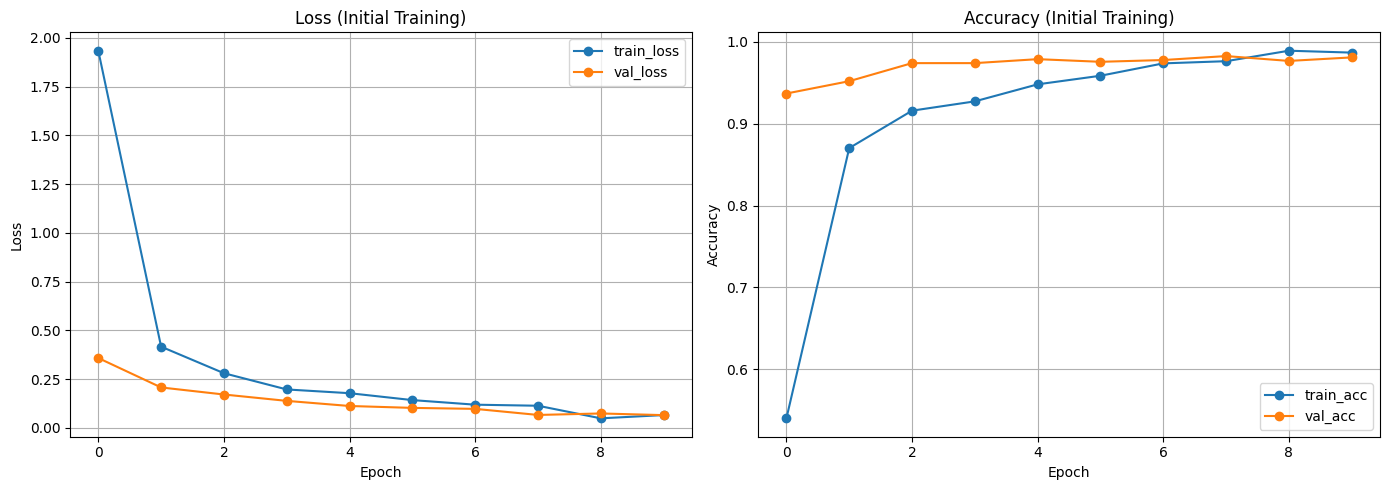

In [30]:
# CELL 15 — Plot Initial Training Results

import matplotlib.pyplot as plt

h = history1.history

plt.figure(figsize=(14,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(h['loss'], label='train_loss', marker='o')
plt.plot(h['val_loss'], label='val_loss', marker='o')
plt.title("Loss (Initial Training)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(h['accuracy'], label='train_acc', marker='o')
plt.plot(h['val_accuracy'], label='val_acc', marker='o')
plt.title("Accuracy (Initial Training)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


In [31]:
# CELL 16 — Retrain Model (Merge train+val, small val split for callbacks)

from sklearn.model_selection import train_test_split

merged = pd.concat([train_df, val_df]).reset_index(drop=True)
print("Merged training+validation size:", len(merged))

# small val split from merged for callbacks
train_sub, val_sub = train_test_split(
    merged,
    test_size=0.1,
    stratify=merged['label'],
    random_state=SEED
)

train_ds_re = df_to_tf_dataset(train_sub, shuffle=True)
val_ds_re   = df_to_tf_dataset(val_sub, shuffle=False)
test_ds_re  = df_to_tf_dataset(test_df, shuffle=False)

# recompute class weights for merged training
y_train_re = train_sub['label'].map(label_to_idx).values
N = len(y_train_re)
C = len(CLASS_NAMES)
manual_weights_re = {i: N/(C*sum(y_train_re==i)) for i in range(C)}

# rebuild fresh model within existing strategy
with strategy.scope():
    model_re = build_model()
    model_re.compile(
        optimizer=keras.optimizers.Adam(learning_rate=LR),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

# callbacks
callbacks_re = [
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1),
    keras.callbacks.ModelCheckpoint("best_model_retrain.h5", monitor='val_loss', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True, verbose=1)
]

# retrain
start = time.time()
history2 = model_re.fit(
    train_ds_re,
    validation_data=val_ds_re,
    epochs=RETRAIN_EPOCHS,
    class_weight=manual_weights_re,
    callbacks=callbacks_re
)
print("Retrain time (s):", time.time() - start)

# Save history
pd.DataFrame(history2.history).to_csv("history_retrain.csv", index=False)


Merged training+validation size: 7481
Epoch 1/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 479ms/step - accuracy: 0.3708 - loss: 3.3344
Epoch 1: val_loss improved from None to 0.35783, saving model to best_model_retrain.h5



Epoch 1: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 105s 495ms/step - accuracy: 0.6004 - loss: 1.6482 - val_accuracy: 0.8678 - val_loss: 0.3578 - learning_rate: 0.0010
Epoch 2/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 492ms/step - accuracy: 0.8870 - loss: 0.3733
Epoch 2: val_loss improved from 0.35783 to 0.15302, saving model to best_model_retrain.h5



Epoch 2: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 108s 509ms/step - accuracy: 0.8966 - loss: 0.3377 - val_accuracy: 0.9653 - val_loss: 0.1530 - learning_rate: 0.0010
Epoch 3/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 477ms/step - accuracy: 0.9167 - loss: 0.2645
Epoch 3: val_loss improved from 0.15302 to 0.13628, saving model to best_model_retrain.h5



Epoch 3: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 104s 492ms/step - accuracy: 0.9216 - loss: 0.2368 - val_accuracy: 0.8945 - val_loss: 0.1363 - learning_rate: 0.0010
Epoch 4/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 469ms/step - accuracy: 0.9273 - loss: 0.1984
Epoch 4: val_loss improved from 0.13628 to 0.12853, saving model to best_model_retrain.h5



Epoch 4: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 102s 485ms/step - accuracy: 0.9275 - loss: 0.1948 - val_accuracy: 0.8932 - val_loss: 0.1285 - learning_rate: 0.0010
Epoch 5/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 480ms/step - accuracy: 0.9556 - loss: 0.1404
Epoch 5: val_loss improved from 0.12853 to 0.12616, saving model to best_model_retrain.h5



Epoch 5: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 105s 494ms/step - accuracy: 0.9499 - loss: 0.1552 - val_accuracy: 0.8959 - val_loss: 0.1262 - learning_rate: 0.0010
Epoch 6/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 431ms/step - accuracy: 0.9573 - loss: 0.1356
Epoch 6: val_loss improved from 0.12616 to 0.08565, saving model to best_model_retrain.h5



Epoch 6: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 94s 443ms/step - accuracy: 0.9624 - loss: 0.1414 - val_accuracy: 0.9786 - val_loss: 0.0856 - learning_rate: 0.0010
Epoch 7/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 424ms/step - accuracy: 0.9846 - loss: 0.0832
Epoch 7: val_loss improved from 0.08565 to 0.07276, saving model to best_model_retrain.h5



Epoch 7: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 92s 437ms/step - accuracy: 0.9856 - loss: 0.0833 - val_accuracy: 0.9813 - val_loss: 0.0728 - learning_rate: 0.0010
Epoch 8/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 427ms/step - accuracy: 0.9839 - loss: 0.0822
Epoch 8: val_loss did not improve from 0.07276
211/211 ━━━━━━━━━━━━━━━━━━━━ 92s 437ms/step - accuracy: 0.9820 - loss: 0.0891 - val_accuracy: 0.9786 - val_loss: 0.0866 - learning_rate: 0.0010
Epoch 9/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 426ms/step - accuracy: 0.9886 - loss: 0.0707
Epoch 9: val_loss improved from 0.07276 to 0.06376, saving model to best_model_retrain.h5



Epoch 9: finished saving model to best_model_retrain.h5
211/211 ━━━━━━━━━━━━━━━━━━━━ 93s 438ms/step - accuracy: 0.9895 - loss: 0.0678 - val_accuracy: 0.9786 - val_loss: 0.0638 - learning_rate: 0.0010
Epoch 10/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 428ms/step - accuracy: 0.9934 - loss: 0.0316
Epoch 10: val_loss did not improve from 0.06376
211/211 ━━━━━━━━━━━━━━━━━━━━ 93s 438ms/step - accuracy: 0.9890 - loss: 0.0506 - val_accuracy: 0.9680 - val_loss: 0.1016 - learning_rate: 0.0010
Epoch 11/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.9914 - loss: 0.0605
Epoch 11: val_loss did not improve from 0.06376
211/211 ━━━━━━━━━━━━━━━━━━━━ 94s 444ms/step - accuracy: 0.9917 - loss: 0.0484 - val_accuracy: 0.9786 - val_loss: 0.0998 - learning_rate: 0.0010
Epoch 12/15
211/211 ━━━━━━━━━━━━━━━━━━━━ 0s 421ms/step - accuracy: 0.9922 - loss: 0.0399
Epoch 12: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 12: val_loss did not improve from 0.06376
211/211 ━━━━━━━━━━━━━━

# Re-Training Results

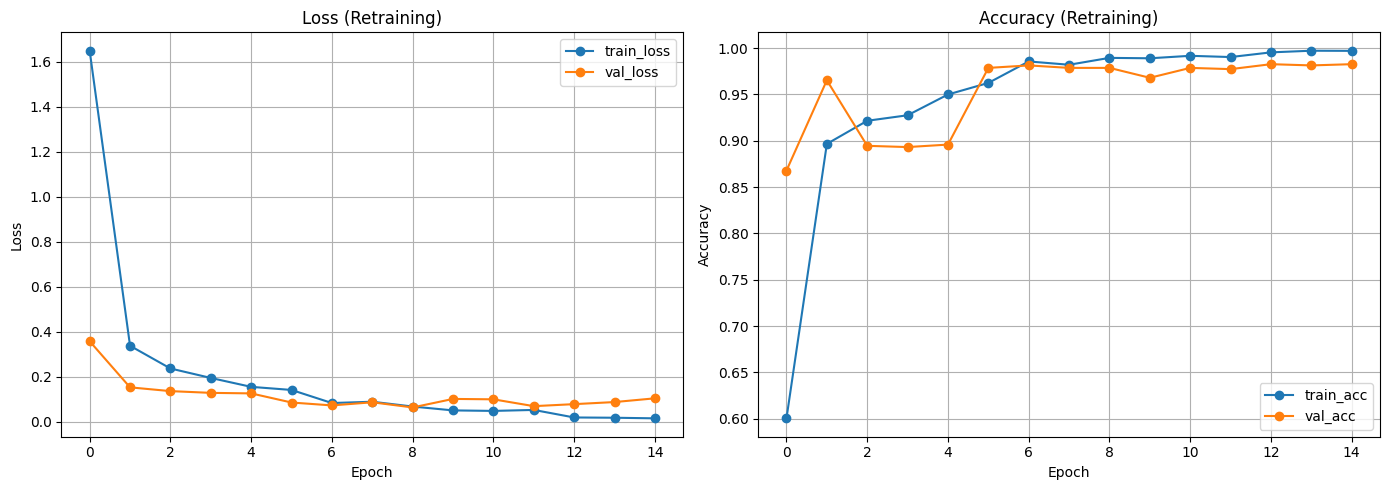

In [32]:
# CELL 17 — Plot Retrain History

h2 = history2.history

plt.figure(figsize=(14,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(h2['loss'], label='train_loss', marker='o')
plt.plot(h2['val_loss'], label='val_loss', marker='o')
plt.title("Loss (Retraining)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(h2['accuracy'], label='train_acc', marker='o')
plt.plot(h2['val_accuracy'], label='val_acc', marker='o')
plt.title("Accuracy (Retraining)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


# Performance Evaluation 

Test overall accuracy: 0.9865446716899893

Classification report:
                precision    recall  f1-score   support

     Adialer.C     1.0000    1.0000    1.0000        24
     Agent.FYI     1.0000    1.0000    1.0000        23
     Allaple.A     0.9966    1.0000    0.9983       589
     Allaple.L     1.0000    1.0000    1.0000       318
 Alueron.gen!J     1.0000    1.0000    1.0000        39
     Autorun.K     1.0000    1.0000    1.0000        21
       C2LOP.P     0.8750    0.9655    0.9180        29
   C2LOP.gen!g     0.9286    0.9750    0.9512        40
Dialplatform.B     1.0000    1.0000    1.0000        35
     Dontovo.A     1.0000    1.0000    1.0000        32
      Fakerean     0.9868    0.9868    0.9868        76
 Instantaccess     1.0000    1.0000    1.0000        86
    Lolyda.AA1     1.0000    1.0000    1.0000        42
    Lolyda.AA2     1.0000    1.0000    1.0000        36
    Lolyda.AA3     1.0000    1.0000    1.0000        24
     Lolyda.AT     1.0000    1.0000  

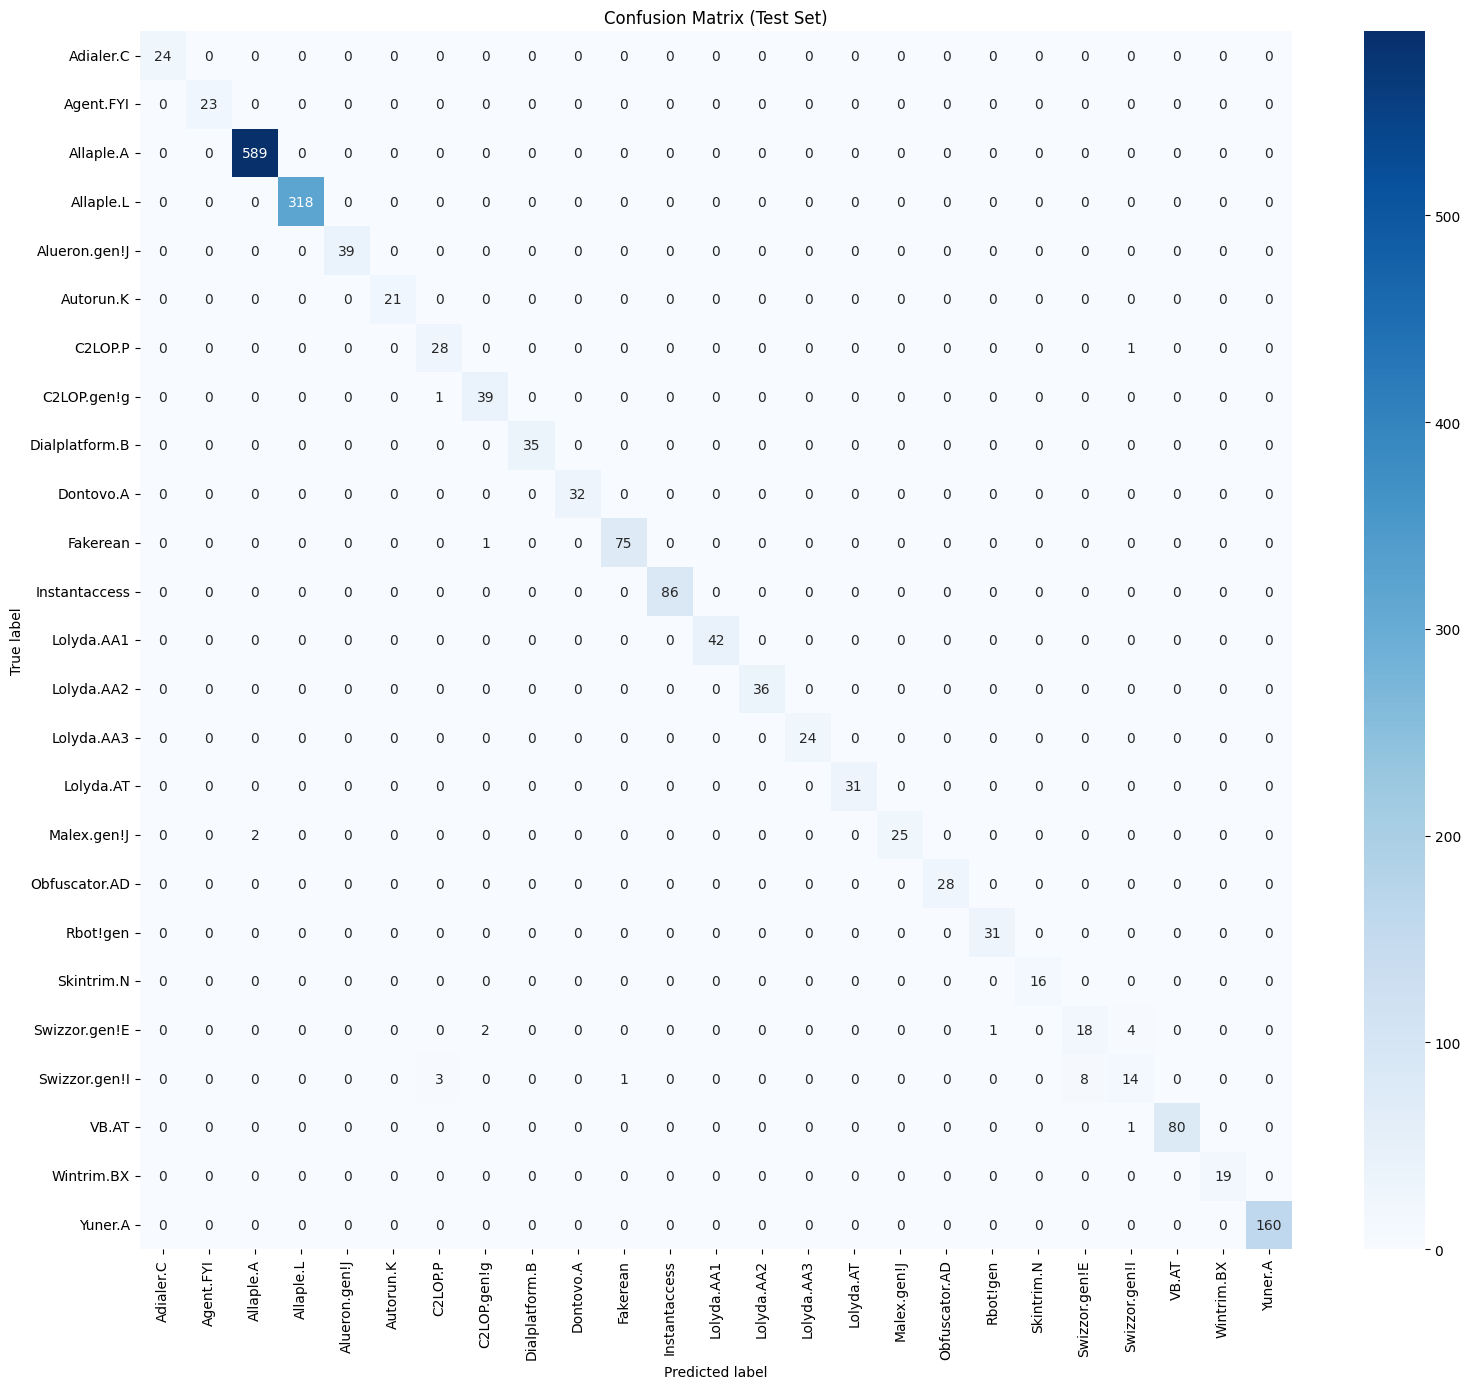

Saved final_model.h5, final_model.keras, and test_predictions.csv


In [33]:
# CELL 18 — Final Test Evaluation: Classification Report & Confusion Matrix using Best Retrained Model

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Load best retrained model
best = keras.models.load_model("best_model_retrain.h5")

y_true, y_pred, y_prob = [], [], []

# Predict on test dataset
for imgs, labs in test_ds_re:
    probs = best.predict(imgs, verbose=0)
    preds = np.argmax(probs, axis=1)
    y_true.extend(labs.numpy())
    y_pred.extend(preds.tolist())
    y_prob.extend(probs.tolist())

# Accuracy
test_acc = np.mean(np.array(y_true) == np.array(y_pred))
print("Test overall accuracy:", test_acc)

# Classification report
print("\nClassification report:")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES, digits=4))

# Confusion matrix with annotations
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16,14))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.xlabel('Predicted label')
plt.ylabel('True label')
plt.title('Confusion Matrix (Test Set)')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig("confusion_test.png")
plt.show()

# Save predictions as CSV
pd.DataFrame({"true": y_true, "pred": y_pred}).to_csv("test_predictions.csv", index=False)

# Save final model in both HDF5 and recommended Keras format
best.save("final_model.h5")
best.save("final_model.keras")  # recommended modern format
print("Saved final_model.h5, final_model.keras, and test_predictions.csv")


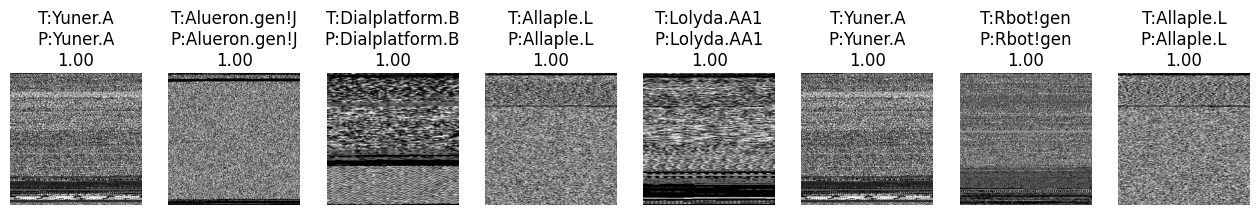

In [34]:
# CELL 19 — Show a few Test Samples with Predicted Labels

sample_df = test_df.sample(n=min(8, len(test_df)), random_state=SEED).reset_index(drop=True)
imgs = []

for p in sample_df['filepath']:
    img = tf.io.read_file(p)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255.0  # normalize to [0,1] for matplotlib
    imgs.append(img.numpy())

imgs = np.stack(imgs, axis=0)
probs = best.predict(imgs, verbose=0)
preds = np.argmax(probs, axis=1)

plt.figure(figsize=(16,4))
for i in range(len(imgs)):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(imgs[i])  # now values are 0-1, no need to cast
    plt.title(f"T:{sample_df.loc[i,'label']}\nP:{CLASS_NAMES[preds[i]]}\n{probs[i,preds[i]]:.2f}")
    plt.axis('off')
plt.show()


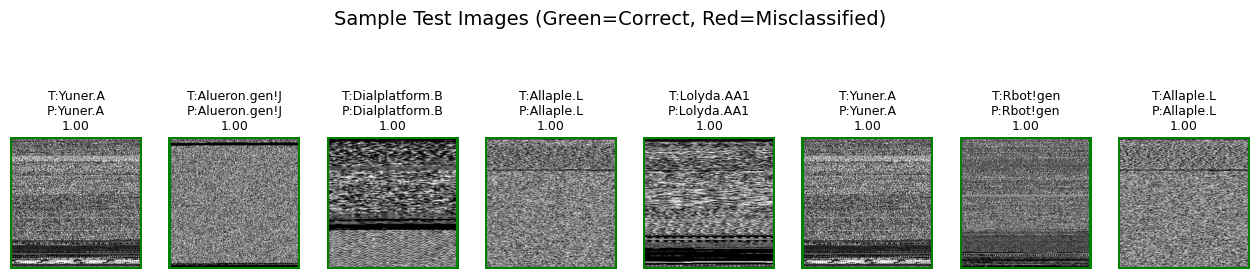

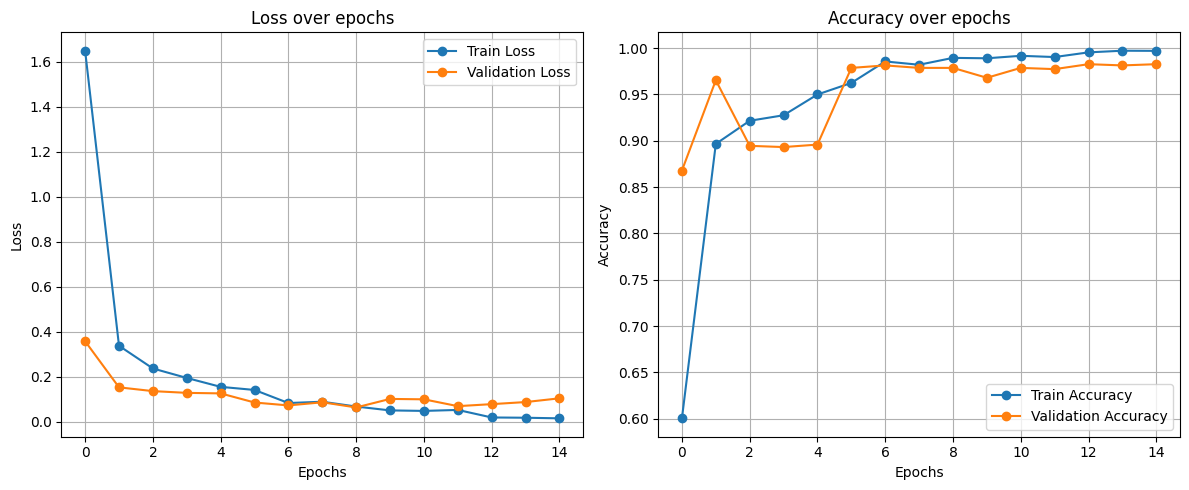

In [35]:
# CELL 20 — Show Test Samples with Correct/Misclassified highlights and
# Plot Training/Validation Curves

import matplotlib.pyplot as plt
import matplotlib.patches as patches

# ---------- 0. SELECT the correct history object ----------

# Can choose either history1 or history2 – both contain full training logs
history = history2   

# ---------- 1. Show sample test images ----------
sample_df = test_df.sample(n=min(8, len(test_df)), random_state=SEED).reset_index(drop=True)
imgs = []

for p in sample_df['filepath']:
    img = tf.io.read_file(p)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMAGE_SIZE)
    imgs.append(img.numpy())

imgs = np.stack(imgs, axis=0)
probs = best.predict(imgs, verbose=0)
preds = np.argmax(probs, axis=1)

plt.figure(figsize=(16,4))
for i in range(len(imgs)):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(imgs[i].astype('uint8'))
    
    color = 'green' if sample_df.loc[i,'label'] == CLASS_NAMES[preds[i]] else 'red'
    plt.gca().add_patch(patches.Rectangle((0,0), IMAGE_SIZE[1]-1, IMAGE_SIZE[0]-1,
                                          linewidth=3, edgecolor=color, facecolor='none'))
    
    plt.title(f"T:{sample_df.loc[i,'label']}\nP:{CLASS_NAMES[preds[i]]}\n{probs[i,preds[i]]:.2f}", fontsize=9)
    plt.axis('off')

plt.suptitle("Sample Test Images (Green=Correct, Red=Misclassified)", fontsize=14)
plt.show()


# ---------- 2. PLOT TRAINING AND VALIDATION CURVES ----------

plt.figure(figsize=(12,5))

# Loss plot
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss', marker='o')
plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
plt.title('Loss over epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy plot
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
plt.title('Accuracy over epochs')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


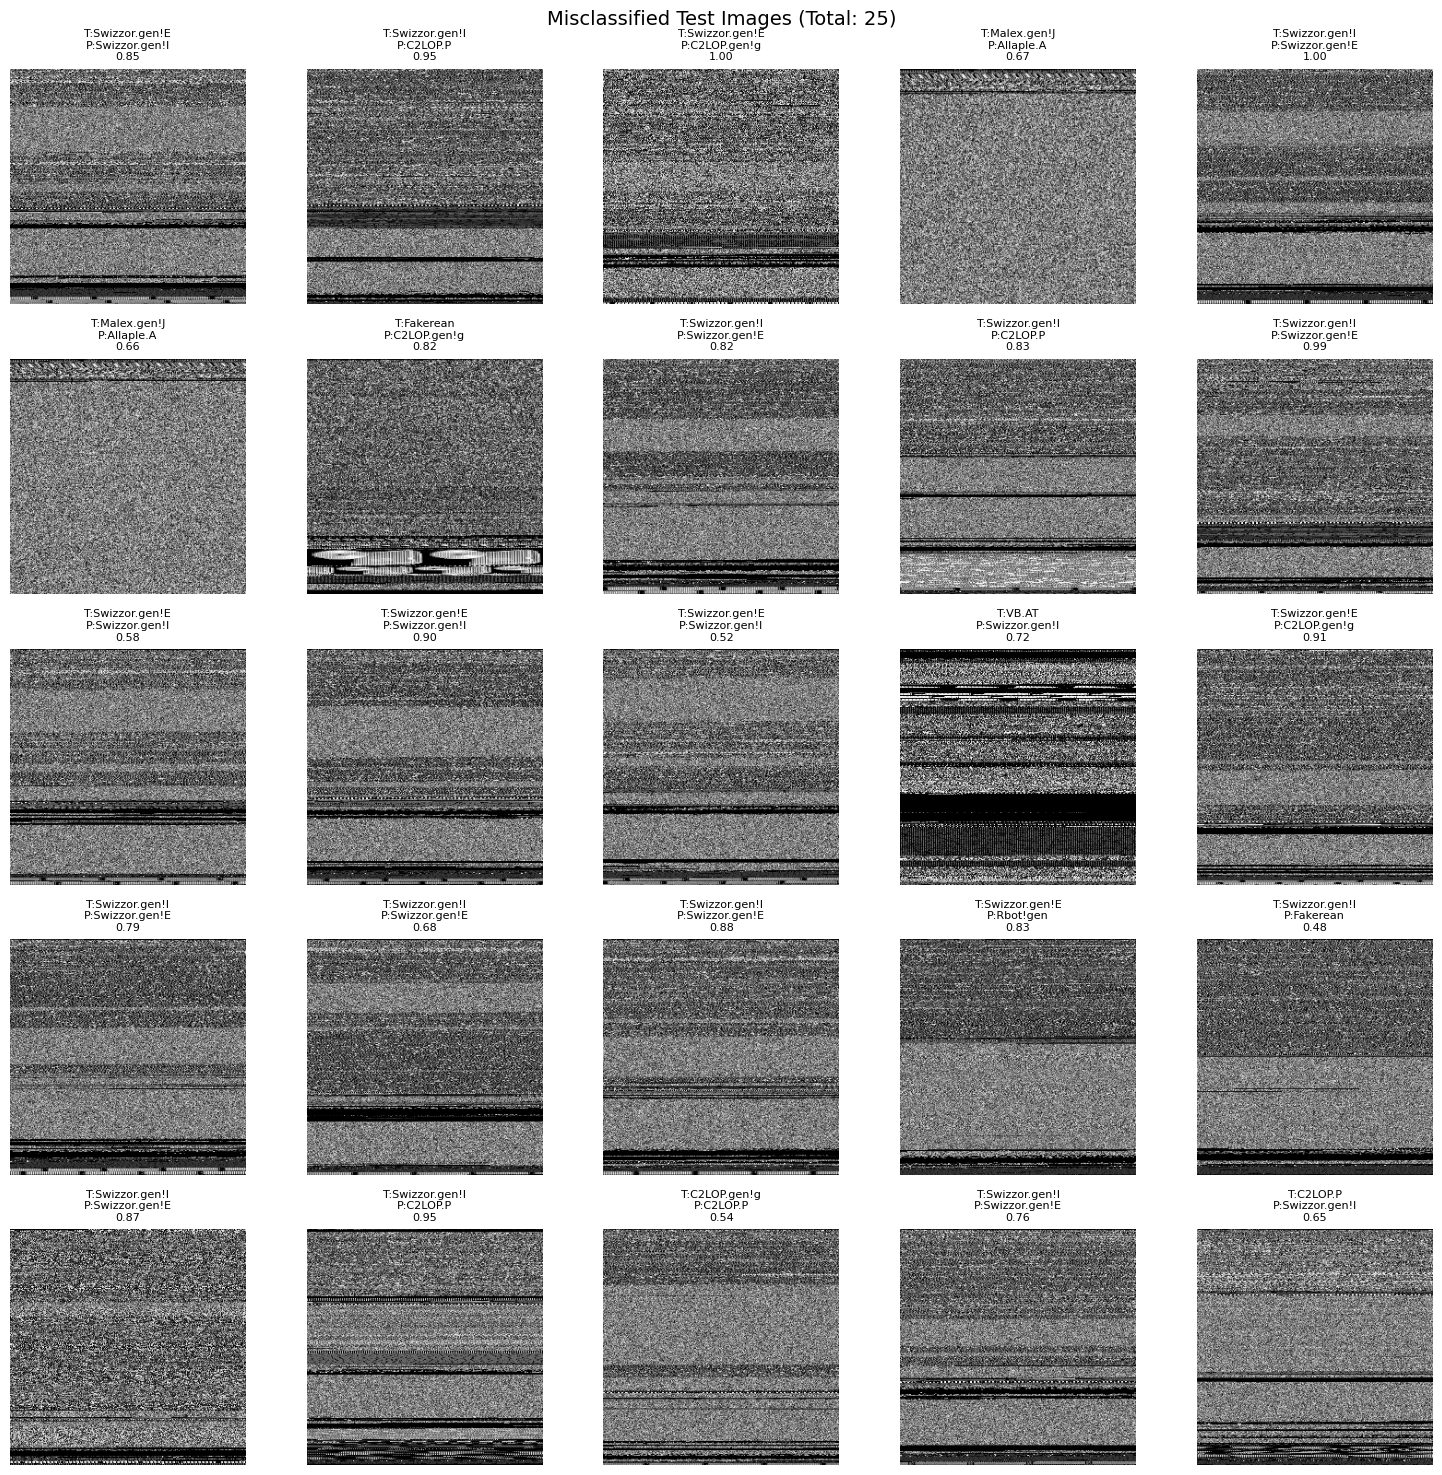

In [36]:
# CELL 21 — Display all Misclassified Test Images from the Test set

import math

# Collect all misclassified images
misclassified_indices = [i for i, (t, p) in enumerate(zip(y_true, y_pred)) if t != p]

if len(misclassified_indices) == 0:
    print("No misclassified images in the test set!")
else:
    n_images = len(misclassified_indices)
    n_cols = 5  # number of columns in the grid
    n_rows = math.ceil(n_images / n_cols)

    plt.figure(figsize=(n_cols*3, n_rows*3))
    for i, idx in enumerate(misclassified_indices):
        img_path = test_df.iloc[idx]['filepath']
        img = tf.io.read_file(img_path)
        img = tf.io.decode_image(img, channels=3, expand_animations=False)
        img = tf.image.resize(img, IMAGE_SIZE).numpy()

        plt.subplot(n_rows, n_cols, i+1)
        plt.imshow(img.astype('uint8'))
        plt.title(f"T:{CLASS_NAMES[y_true[idx]]}\nP:{CLASS_NAMES[y_pred[idx]]}\n{y_prob[idx][y_pred[idx]]:.2f}", fontsize=8)
        plt.axis('off')

    plt.suptitle(f"Misclassified Test Images (Total: {n_images})", fontsize=14)
    plt.tight_layout()
    plt.show()


In [37]:
# CELL 22 — Class-wise Success Rate and Overall Accuracy

import pandas as pd
import numpy as np

# Convert y_true and y_pred to numpy arrays for easier handling
y_true_arr = np.array(y_true)
y_pred_arr = np.array(y_pred)

class_success = {}
for i, cls_name in enumerate(CLASS_NAMES):
    cls_indices = np.where(y_true_arr == i)[0]
    if len(cls_indices) > 0:
        cls_accuracy = np.mean(y_pred_arr[cls_indices] == i)
        class_success[cls_name] = cls_accuracy
    else:
        class_success[cls_name] = np.nan  # no samples of this class in test set

# Create DataFrame for better visualization
success_df = pd.DataFrame({
    "Class": list(class_success.keys()),
    "Success Rate": [v for v in class_success.values()]
})

success_df['Success Rate (%)'] = success_df['Success Rate'] * 100
success_df = success_df.sort_values(by='Success Rate', ascending=False).reset_index(drop=True)

# Overall accuracy
overall_accuracy = np.mean(y_true_arr == y_pred_arr) * 100

print(f"Overall test accuracy: {overall_accuracy:.2f}%\n")
print("Per-class success rate:")
display(success_df)


Overall test accuracy: 98.65%

Per-class success rate:


,Class,Success Rate,Success Rate (%)
0,Adialer.C,1.000000,100.000000
1,Instantaccess,1.000000,100.000000
2,Wintrim.BX,1.000000,100.000000
3,Skintrim.N,1.000000,100.000000
4,Rbot!gen,1.000000,100.000000
5,Obfuscator.AD,1.000000,100.000000
6,Lolyda.AT,1.000000,100.000000
7,Lolyda.AA3,1.000000,100.000000
8,Lolyda.AA2,1.000000,100.000000
9,Agent.FYI,1.000000,100.000000


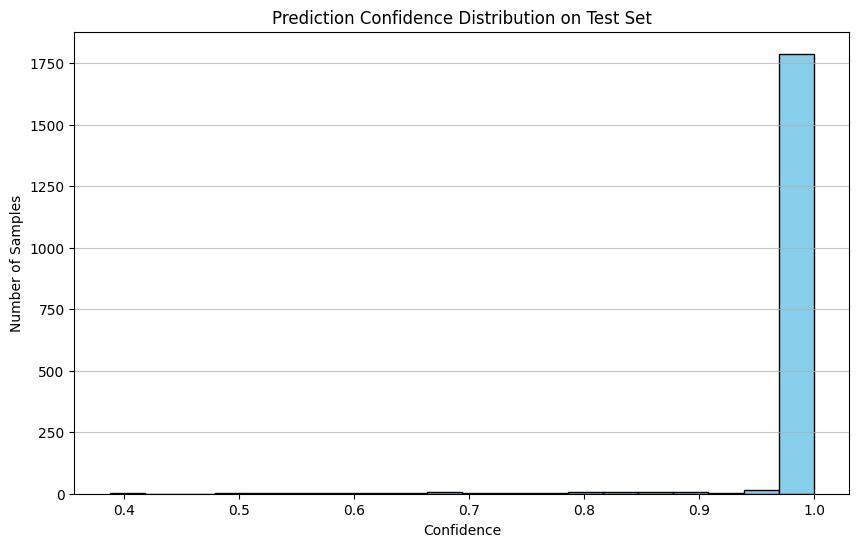

In [38]:
# CELL 23 — Prediction Confidence Histogram (Histogram of Model Confidence for each prediction.)

import matplotlib.pyplot as plt

# Convert probs to max confidence per sample
max_confidences = np.max(y_prob, axis=1)

plt.figure(figsize=(10,6))
plt.hist(max_confidences, bins=20, color='skyblue', edgecolor='black')
plt.title("Prediction Confidence Distribution on Test Set")
plt.xlabel("Confidence")
plt.ylabel("Number of Samples")
plt.grid(axis='y', alpha=0.75)
plt.show()


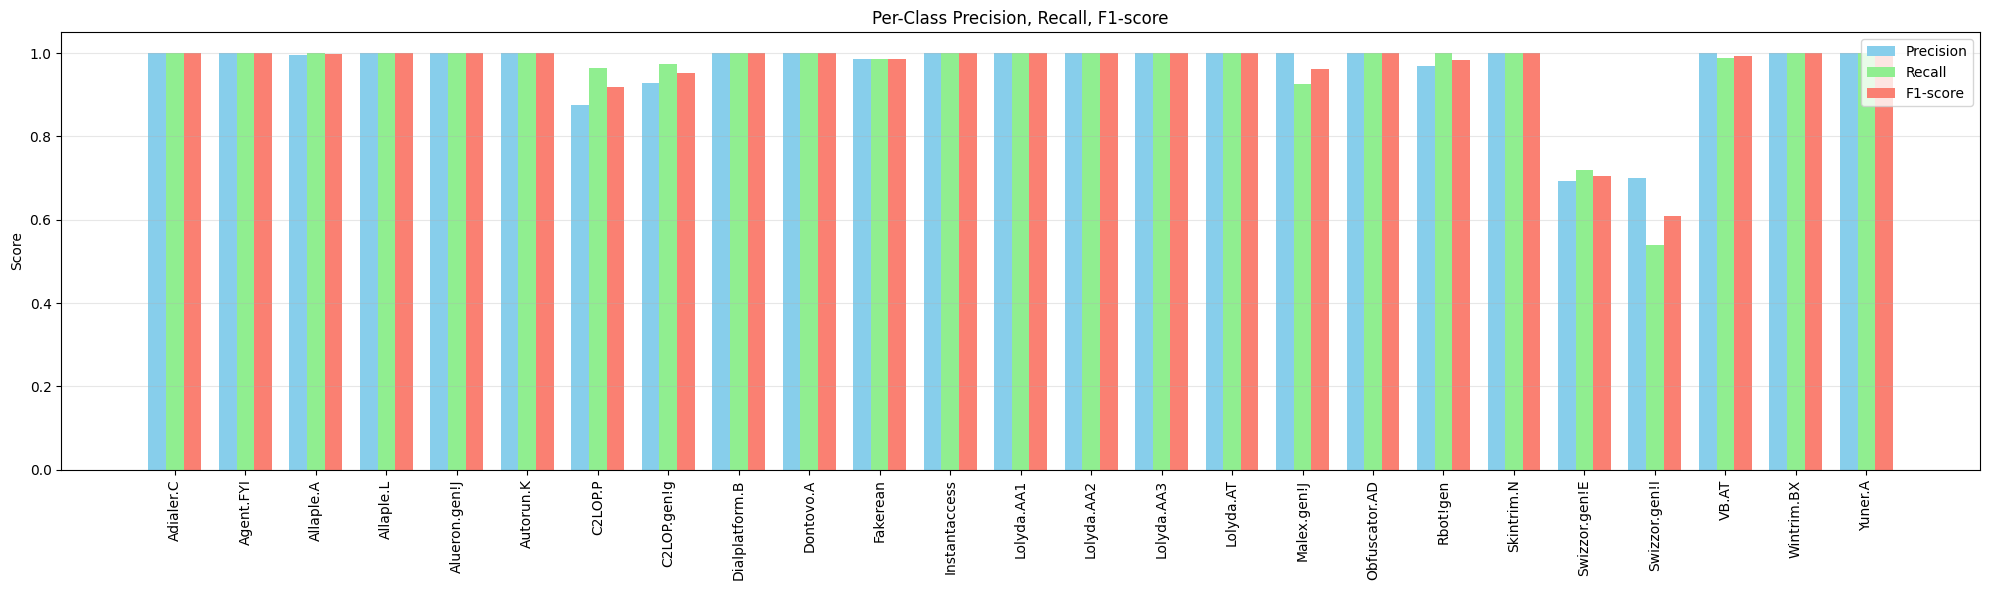

In [39]:
# CELL 24 — Bar Chart of F1-Score, Precision, Recall (per Class)

from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

x = np.arange(len(CLASS_NAMES))
width = 0.25

plt.figure(figsize=(20,6))
plt.bar(x - width, precision, width, label='Precision', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, CLASS_NAMES, rotation=90)
plt.ylabel("Score")
plt.title("Per-Class Precision, Recall, F1-score")
plt.ylim(0,1.05)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


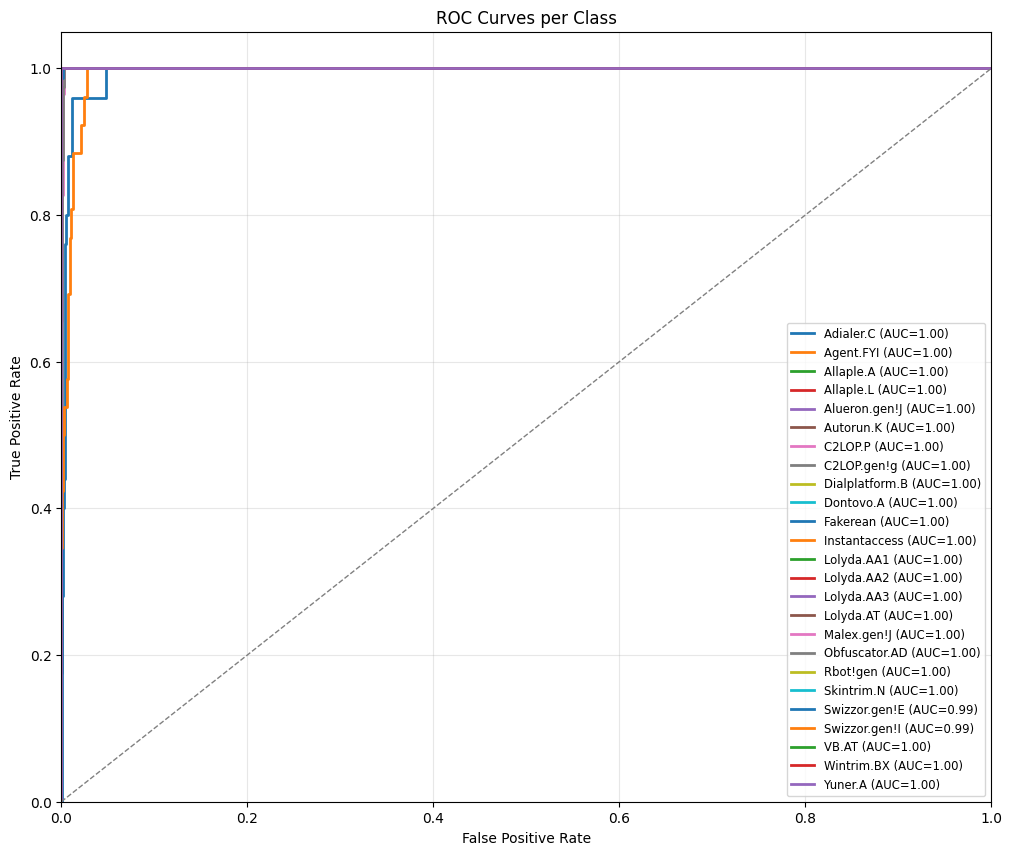

In [40]:
# CELL 25 — ROC Curves per Class

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Binarize labels for multi-class ROC
y_true_bin = label_binarize(y_true, classes=range(len(CLASS_NAMES)))
y_prob_np = np.array(y_prob)

plt.figure(figsize=(12,10))
for i in range(len(CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:,i], y_prob_np[:,i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], color='gray', lw=1, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves per Class')
plt.legend(loc='lower right', fontsize='small')
plt.grid(alpha=0.3)
plt.show()


C:\Users\Nguyen Thien Khai\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: [['input_layer_1']]
Received: inputs=['Tensor(shape=(1, 256, 256, 3))']
  warnings.warn(msg)


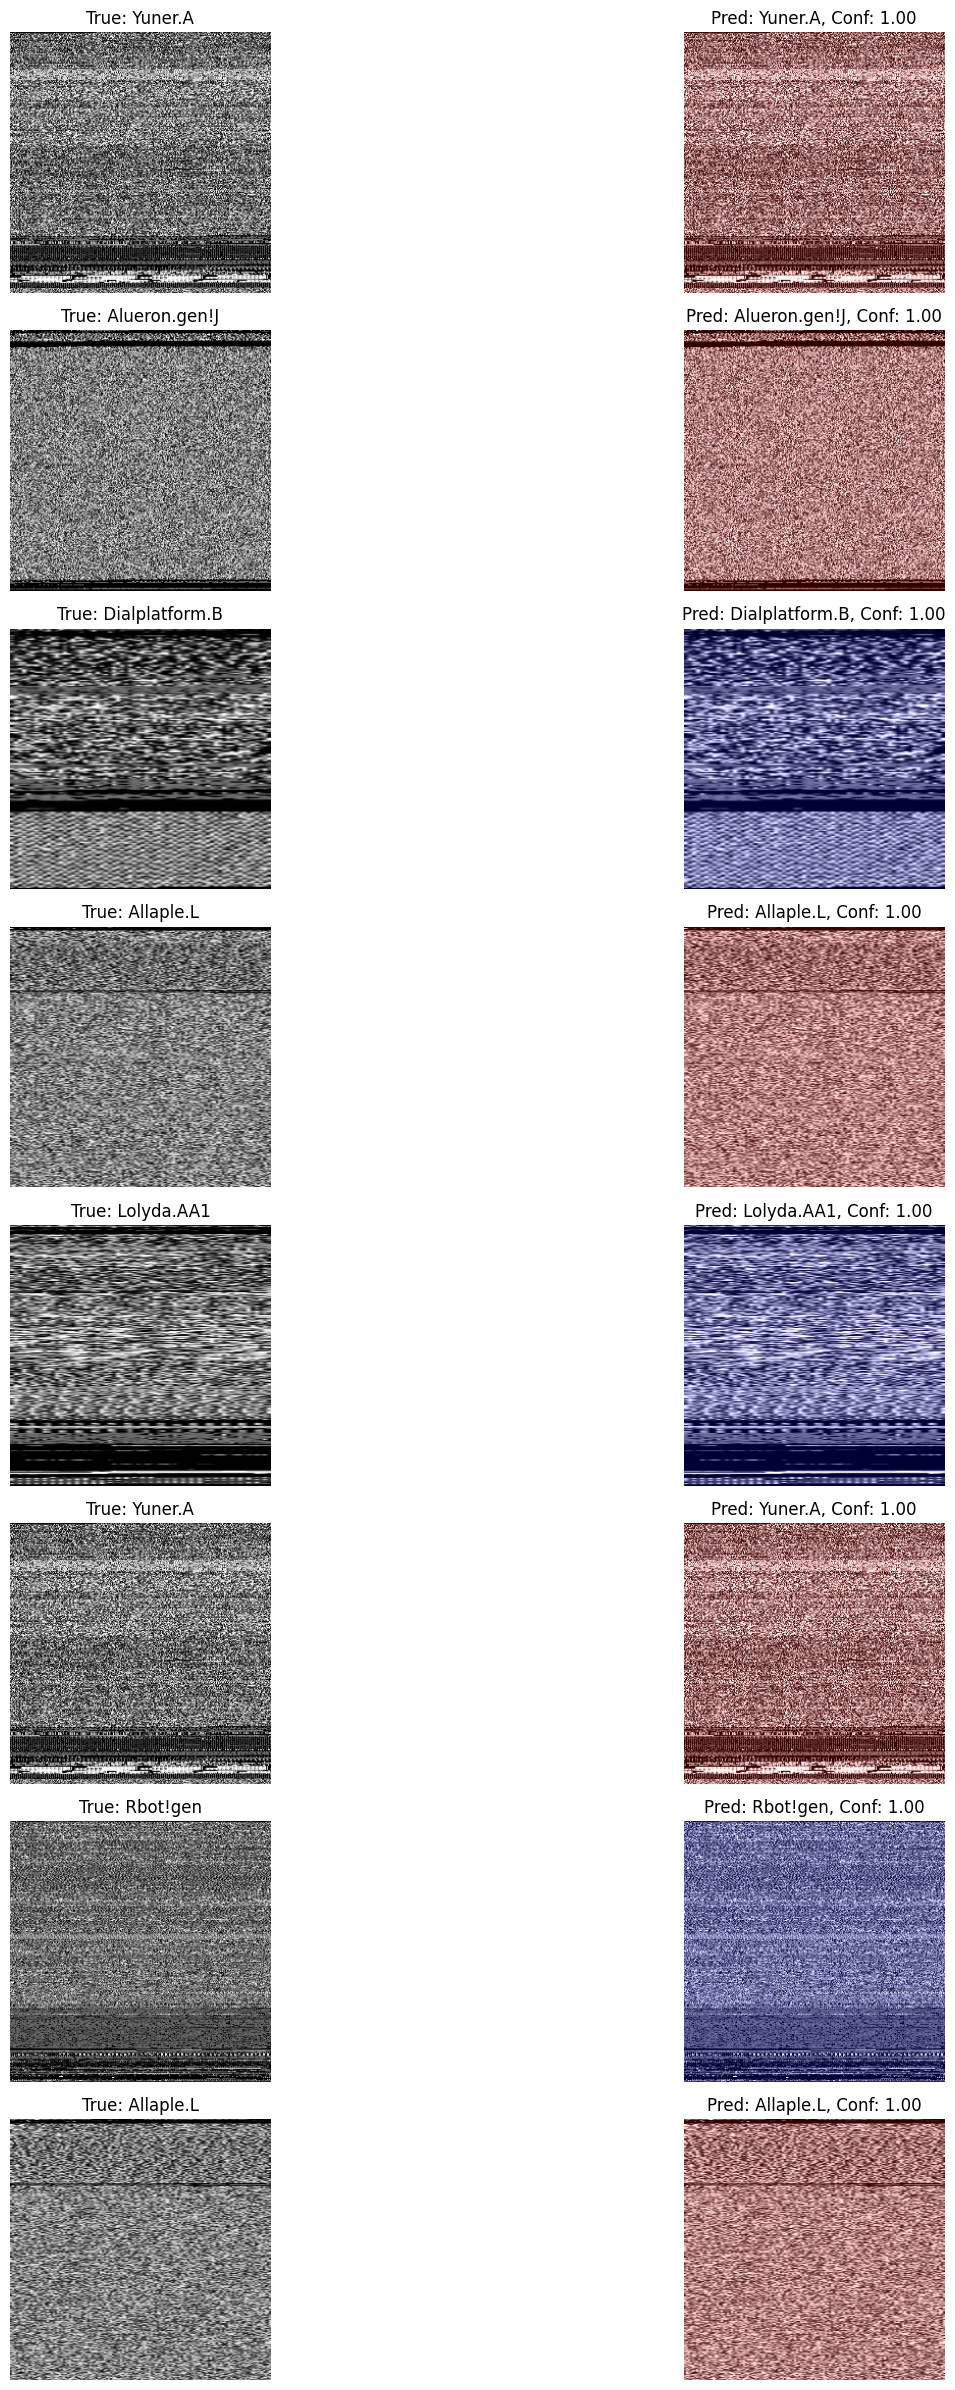

In [41]:
# CELL 26* — Grad-CAM per sample (robust)

import matplotlib.cm as cm  
plt.figure(figsize=(18, 3 * len(sample_df)))

for idx, row in sample_df.iterrows():
    img_path = row['filepath']
    true_label = row['label']

    # Load and preprocess image
    img = tf.io.read_file(img_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMAGE_SIZE)
    img_array = tf.expand_dims(img, axis=0) / 255.0

    # Grad-CAM
    last_conv_layer = best.get_layer(index=-4)  
    grad_model = tf.keras.models.Model([best.inputs], [last_conv_layer.output, best.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    # Compute gradients
    grads = tape.gradient(loss, conv_outputs)

    # Reduce over spatial dimensions if present
    if len(grads.shape) == 4:  # [batch, H, W, C]
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
        conv_outputs = conv_outputs[0]
    elif len(grads.shape) == 3:  # [batch, H*W, C] or [H, W, C]
        pooled_grads = tf.reduce_mean(grads, axis=(0, 1))
        conv_outputs = conv_outputs[0]
    elif len(grads.shape) == 2:  # [batch, C]
        pooled_grads = tf.reduce_mean(grads, axis=0)
        conv_outputs = conv_outputs[0][tf.newaxis, tf.newaxis, :]
    else:
        raise ValueError("Unexpected conv/grads shape:", grads.shape)

    # Grad-CAM heatmap
    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMAGE_SIZE)
    heatmap = tf.squeeze(heatmap)

    # Overlay
    heatmap_rgb = cm.jet(heatmap.numpy())[:, :, :3]  
    overlay = 0.4 * heatmap_rgb + img_array[0].numpy()

    # Plot Original
    plt.subplot(len(sample_df), 2, idx*2 + 1)
    plt.imshow(img_array[0])
    plt.title(f"True: {true_label}")
    plt.axis('off')

    # Plot Grad-CAM overlay
    plt.subplot(len(sample_df), 2, idx*2 + 2)
    plt.imshow(np.clip(overlay, 0, 1))
    plt.title(f"Pred: {CLASS_NAMES[pred_index.numpy()]}, Conf: {predictions[0,pred_index]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.show()


**Our model is generally confident (mostly red). Having a mix of Red, Yellow and Blue is realistic and good. This shows very good-confidence predictions and it’s learning meaningful features rather than just blindly activating everywhere.**

In [42]:
# CELL 27 — Save ALL Project Result Plots as PNGs 

import os
import matplotlib.cm as cm
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
import numpy as np
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, confusion_matrix

# 1️⃣ Create folder
output_dir = "results_plots"
os.makedirs(output_dir, exist_ok=True)

# -------------------- 2️⃣ Sample Test Images --------------------
plt.figure(figsize=(16,4))
for i in range(len(imgs)):
    plt.subplot(1, len(imgs), i+1)
    plt.imshow(imgs[i].astype('uint8'))
    color = 'green' if sample_df.loc[i,'label'] == CLASS_NAMES[preds[i]] else 'red'
    plt.gca().add_patch(patches.Rectangle((0,0), IMAGE_SIZE[1]-1, IMAGE_SIZE[0]-1,
                                          linewidth=3, edgecolor=color, facecolor='none'))
    plt.title(f"T:{sample_df.loc[i,'label']}\nP:{CLASS_NAMES[preds[i]]}\n{probs[i,preds[i]]:.2f}", fontsize=9)
    plt.axis('off')
plt.suptitle("Sample Test Images (Green=Correct, Red=Misclassified)", fontsize=14)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "sample_test_images.png"))
plt.close()

# -------------------- 3️⃣ Training/Validation Loss & Accuracy --------------------
if 'history' in locals():
    plt.figure(figsize=(12,5))
    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss', marker='o')
    plt.plot(history.history['val_loss'], label='Validation Loss', marker='o')
    plt.title('Loss over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.grid(True)
    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Accuracy', marker='o')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy', marker='o')
    plt.title('Accuracy over epochs')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(os.path.join(output_dir, "train_val_curves.png"))
    plt.close()

# -------------------- 4️⃣ Grad-CAM Overlays --------------------
plt.figure(figsize=(18, 3 * len(sample_df)))
for idx, row in sample_df.iterrows():
    img_path = row['filepath']
    true_label = row['label']

    # Load & preprocess
    img = tf.io.read_file(img_path)
    img = tf.io.decode_image(img, channels=3, expand_animations=False)
    img = tf.image.resize(img, IMAGE_SIZE)
    img_array = tf.expand_dims(img, axis=0) / 255.0

    # Grad-CAM
    last_conv_layer = best.get_layer(index=-4)
    grad_model = tf.keras.models.Model([best.inputs], [last_conv_layer.output, best.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        pred_index = tf.argmax(predictions[0])
        loss = predictions[:, pred_index]

    grads = tape.gradient(loss, conv_outputs)

    if len(grads.shape) == 4:
        pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))
        conv_outputs = conv_outputs[0]
    elif len(grads.shape) == 3:
        pooled_grads = tf.reduce_mean(grads, axis=(0,1))
        conv_outputs = conv_outputs[0]
    elif len(grads.shape) == 2:
        pooled_grads = tf.reduce_mean(grads, axis=0)
        conv_outputs = conv_outputs[0][tf.newaxis, tf.newaxis, :]
    else:
        raise ValueError("Unexpected conv/grads shape:", grads.shape)

    heatmap = tf.reduce_sum(tf.multiply(conv_outputs, pooled_grads), axis=-1)
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= tf.reduce_max(heatmap) + 1e-8
    heatmap = tf.image.resize(heatmap[..., tf.newaxis], IMAGE_SIZE)
    heatmap = tf.squeeze(heatmap)

    heatmap_rgb = cm.jet(heatmap.numpy())[:, :, :3]
    overlay = 0.4 * heatmap_rgb + img_array[0].numpy()

    plt.subplot(len(sample_df), 2, idx*2 + 1)
    plt.imshow(img_array[0])
    plt.title(f"True: {true_label}")
    plt.axis('off')

    plt.subplot(len(sample_df), 2, idx*2 + 2)
    plt.imshow(np.clip(overlay,0,1))
    plt.title(f"Pred: {CLASS_NAMES[pred_index.numpy()]}, Conf: {predictions[0,pred_index]:.2f}")
    plt.axis('off')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, "gradcam_overlays.png"))
plt.close()

# -------------------- 5️⃣ Confidence Histogram --------------------
plt.figure(figsize=(12,6))
pred_probs = np.max(probs, axis=1)  # use full test predictions
plt.hist(pred_probs, bins=20, color='skyblue', edgecolor='black')
plt.title("Confidence Histogram of Test Predictions")
plt.xlabel("Prediction Confidence")
plt.ylabel("Number of Samples")
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confidence_histogram.png"))
plt.close()

# -------------------- 6️⃣ ROC Curves (One vs Rest) --------------------
# Predict on all test images
all_test_imgs = np.stack([tf.image.resize(tf.io.decode_image(tf.io.read_file(p), channels=3, expand_animations=False), IMAGE_SIZE) 
                          for p in test_df['filepath']], axis=0) / 255.0
y_true = label_binarize([CLASS_NAMES.index(l) for l in test_df['label']], classes=range(len(CLASS_NAMES)))
y_score = best.predict(all_test_imgs, verbose=0)

plt.figure(figsize=(12,10))
for i in range(len(CLASS_NAMES)):
    fpr, tpr, _ = roc_curve(y_true[:, i], y_score[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{CLASS_NAMES[i]} (AUC={roc_auc:.2f})")

plt.plot([0,1], [0,1], 'k--')
plt.title("ROC Curves per Class")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(fontsize=8, ncol=2)
plt.grid(True)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "roc_curves.png"))
plt.close()

# -------------------- 7️⃣ Confusion Matrix --------------------
y_pred = np.argmax(y_score, axis=1)
cmatrix = confusion_matrix([CLASS_NAMES.index(l) for l in test_df['label']], y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cmatrix, annot=True, fmt='d', cmap='Blues', xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES)
plt.title("Confusion Matrix / Misclassification Heatmap")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(output_dir, "confusion_matrix.png"))
plt.close()

print(f"✅ All project result plots saved in folder: {output_dir}")


✅ All project result plots saved in folder: results_plots
